# Netflix Content Trend Analysis 

## Data Imputation and Cleaning 

### Importing libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

# Ensuring inline plotting
%matplotlib inline

# File path quick-setup
FILE = Path('Netflix Dataset 1.csv')


### 1) Loading data

In [2]:
df = pd.read_csv(FILE)
print('Raw rows:', len(df))

Raw rows: 7789


### 2) Basic columns (null val check)

In [3]:
expected_cols = ['Show_Id','Category','Title','Director','Cast','Country','Release_Date','Rating','Duration','Type','Description']
missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing expected columns: {missing_cols}')


### 3) Parsing release date and extracting year

In [4]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year


### 4) Deduplication using Title as basis

In [5]:
df = df.sort_values(['Title','Release_Date']).drop_duplicates(subset=['Title'], keep='first').reset_index(drop=True)


### 5) Setting Primary genre

In [6]:
df['Primary_Genre'] = df['Type'].astype(str).str.split(',').str[0].str.strip()


### 6) Normalizing Duration across types

In [7]:
import re
def parse_duration(row):
    cat = str(row['Category']).strip().lower()
    dur = str(row['Duration']).strip()
    if pd.isna(row['Duration']) or dur.lower() in ['nan','none','']:
        return np.nan
    m = re.search(r"(\d+)", dur)
    if not m:
        return np.nan
    return int(m.group(1))

df['Duration_num'] = df.apply(parse_duration, axis=1)
df['Duration_unit'] = df['Category'].apply(lambda x: 'minutes' if str(x).strip().lower() == 'movie' else 'seasons')



### 7) Handling missing values

In [8]:
cols_check = ['Release_Date','Country','Primary_Genre']
combined_missing_mask = df[cols_check].isna().any(axis=1)
combined_missing_pct = combined_missing_mask.mean()

if combined_missing_pct < 0.10:
    df = df.loc[~combined_missing_mask].reset_index(drop=True)
else:
    for c in ['Country','Primary_Genre']:
        mode_val = df[c].mode(dropna=True)
        if len(mode_val)>0:
            df[c].fillna(mode_val[0], inplace=True)
    med_year = int(df['Release_Year'].median(skipna=True))
    med_date = pd.Timestamp(year=med_year, month=7, day=1)
    df['Release_Date'].fillna(med_date, inplace=True)
    df['Release_Year'] = df['Release_Date'].dt.year



### 8) Cleaning up invalid years

In [9]:
current_year = pd.Timestamp.now().year
df = df[(df['Release_Year'] >= 1900) & (df['Release_Year'] <= current_year)].copy()



## Visualization

### Distribution of Movies vs. TV Shows Over the Years

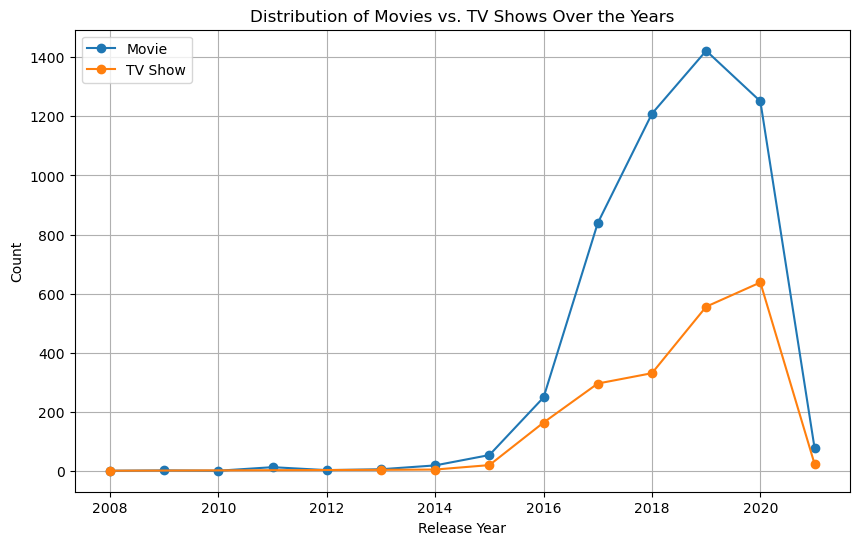

In [10]:
cat_year = df.groupby(['Release_Year','Category']).size().reset_index(name='Count')
plt.figure(figsize=(10,6))
for cat in cat_year['Category'].unique():
    subset = cat_year[cat_year['Category']==cat]
    plt.plot(subset['Release_Year'], subset['Count'], marker='o', label=cat)
plt.title('Distribution of Movies vs. TV Shows Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()



* This graph shows the yearly distribution of movies and TV shows released from 2008 to 2021.
* Both categories saw minimal growth until 2015, after which releases surged sharply.
* Movies peaked around 2019 with over 1,400 releases, while TV shows peaked near 2020 with about 600.
* After 2020, both categories saw a steep decline in production.

### Most common genres and their popularity over years

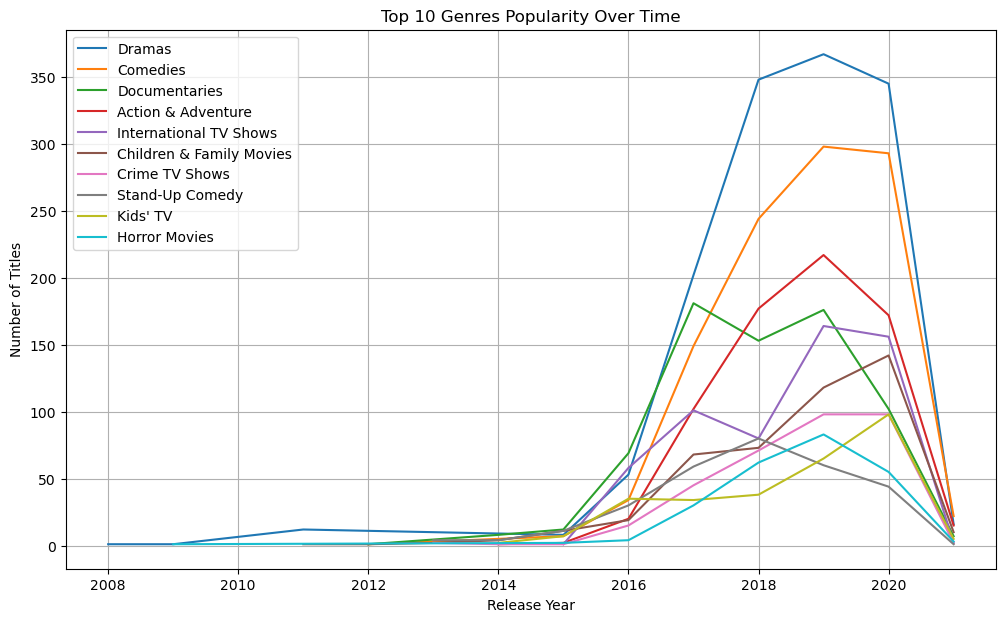

In [11]:
genre_trends = df.groupby(['Release_Year','Primary_Genre']).size().reset_index(name='Count')
top_genres = genre_trends.groupby('Primary_Genre')['Count'].sum().nlargest(10).index
genre_trends = genre_trends[genre_trends['Primary_Genre'].isin(top_genres)]
plt.figure(figsize=(12,7))
for g in top_genres:
    subset = genre_trends[genre_trends['Primary_Genre']==g]
    plt.plot(subset['Release_Year'], subset['Count'], label=g)
plt.title('Top 10 Genres Popularity Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True)
plt.show()



* This graph shows trends in the top 10 genres’ popularity from 2008 to 2021.
* Dramas and comedies dominated, peaking around 2019 with over 350 and 300 titles respectively.
* Most genres saw rapid growth starting from 2015, reaching their highest around 2018–2019.
* After 2020, all genres experienced a noticeable decline in new releases.

### Country contributions

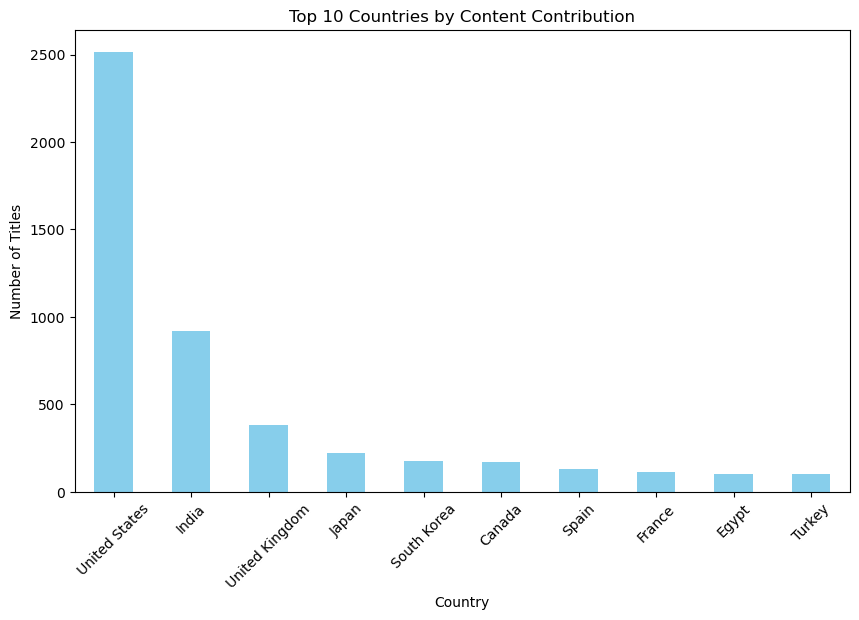

In [12]:
top_countries = df['Country'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Content Contribution')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()



* This chart highlights the top 10 countries contributing to content production.
* The United States dominates with over 2,500 titles, far exceeding other nations.
* India ranks second with around 900 titles, followed by the UK with about 380.
* Other countries like Japan, South Korea, and Canada contribute moderately fewer titles.

### Average duration trend over years

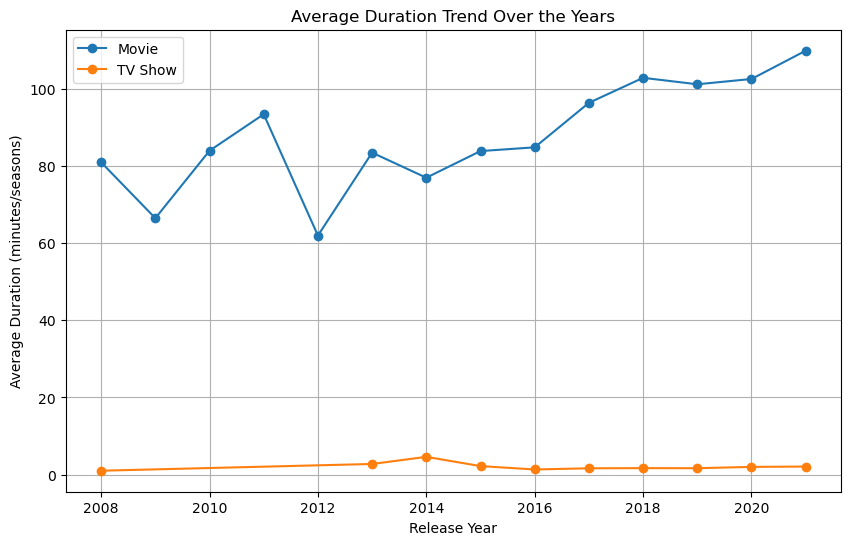

In [13]:
avg_dur = df.groupby(['Release_Year','Category'])['Duration_num'].mean().reset_index()
plt.figure(figsize=(10,6))
for cat in avg_dur['Category'].unique():
    subset = avg_dur[avg_dur['Category']==cat]
    plt.plot(subset['Release_Year'], subset['Duration_num'], marker='o', label=cat)
plt.title('Average Duration Trend Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes/seasons)')
plt.legend()
plt.grid(True)
plt.show()


* The graph compares average duration trends of movies and TV shows from 2008 to 2021.
* Movie durations steadily increased from around 80 to over 100 minutes by 2021.
* TV shows maintained low averages, mostly between 1–4 seasons, with minor variation.
* Overall, movies show a consistent upward trend, while TV show durations remain stable.
* Created seperate graphs below for detaied analysis

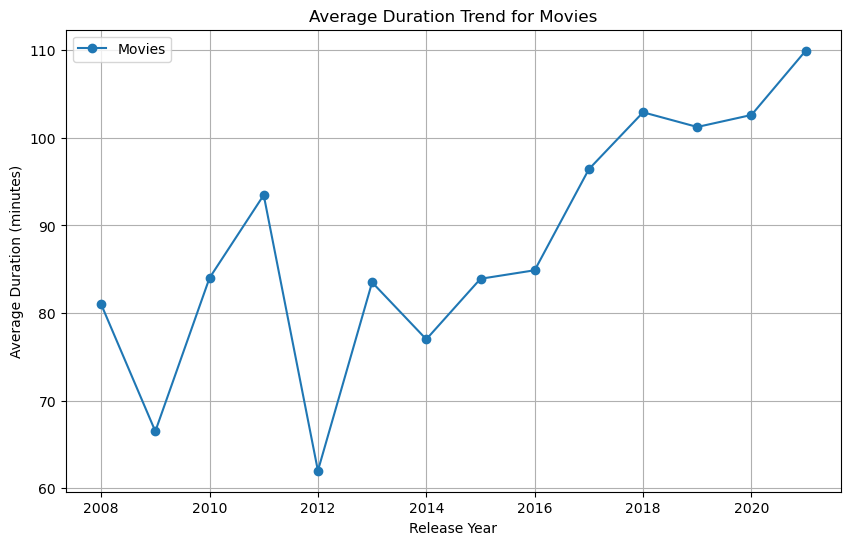

In [14]:
avg_dur = df.groupby(['Release_Year','Category'])['Duration_num'].mean().reset_index()

# Filtering data
movies_data = avg_dur[avg_dur['Category'] == 'Movie']
tv_shows_data = avg_dur[avg_dur['Category'] == 'TV Show']

# Creating the plot for Movies
plt.figure(figsize=(10, 6))
plt.plot(movies_data['Release_Year'], movies_data['Duration_num'], marker='o', label='Movies')
plt.title('Average Duration Trend for Movies')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.grid(True)
plt.legend()
plt.show()



* The above graph shows the average duration trend for movies over the years, from 2008 to 2020.
* The X-axis represents the release years, while the Y-axis shows the average duration in minutes.
* There is a noticeable fluctuation in the movie durations across the years with some peaks, particularly around 2012 and 2020.
* The general trend indicates an increase in the average movie duration from 2016 onwards.

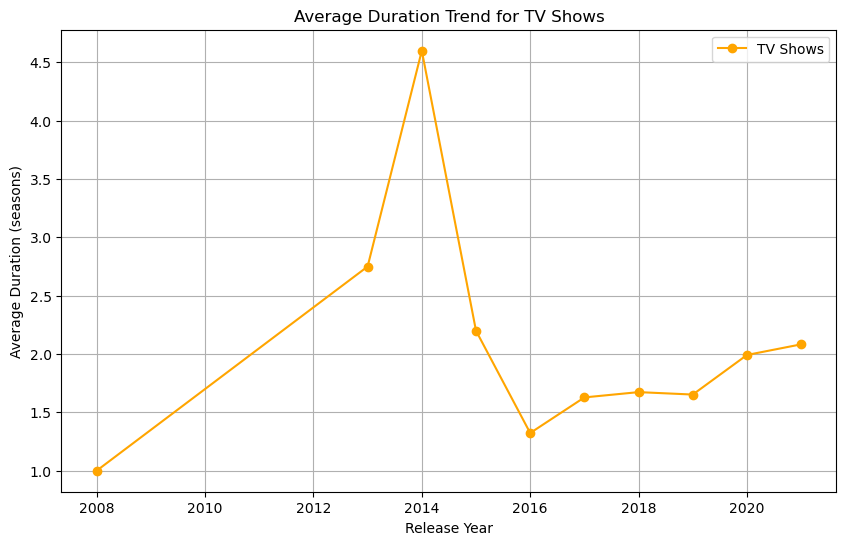

In [15]:
# Creating the plot for TV Shows
plt.figure(figsize=(10, 6))
plt.plot(tv_shows_data['Release_Year'], tv_shows_data['Duration_num'], marker='o', label='TV Shows', color='orange')
plt.title('Average Duration Trend for TV Shows')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (seasons)')
plt.grid(True)
plt.legend()
plt.show()


* The above graph illustrates the average duration trend of TV shows (in seasons) from 2008 to 2021.
* There is a sharp increase in average duration that peaked in 2014 at over 4.5 seasons, followed by a steep decline in the following years.
* We can see from 2016 onward, the duration stabilizes, gradually increasing again but remaining below the 2014 peak.
* Overall, the trend shows volatility early on, with more consistent durations in recent years.